# Tutorial 3. Use SEDR to do batch integration.

Here we use 3 sections from DLPFC data to show the ability of SEDR to integrate batches for the same tissue with the same techniques. 

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad


import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from matplotlib.image import imread

In [2]:
import SEDR

In [3]:
SEDR.fix_seed(1)

In [4]:
String = 'H'
num_clusters = 6

patho_anno = pd.read_csv(f"../../../data/BreastCancer/her2st-master/data/ST-pat/lbl/{String}1_labeled_coordinates.tsv", index_col=0, sep='\t')


adata_st_list_raw = []

for i in range(1, 4):
    # st_count = pd.read_csv("./data/HER2-positive/count-matrices/E%d.tsv.gz" % i, index_col=0, sep='\t')
    # st_meta = pd.read_csv("./data/HER2-positive/spot-selections/E%d_selection.tsv.gz" % i, sep='\t')
    st_count = pd.read_csv(f"../../../data/BreastCancer/her2st-master/data/ST-cnts/{String}{i}.tsv.gz", index_col=0, sep='\t')
    st_meta = pd.read_csv(f"../../../data/BreastCancer/her2st-master/data/ST-spotfiles/{String}{i}_selection.tsv", sep='\t')
    st_meta.index = [str(st_meta['x'][i]) + 'x' + str(st_meta['y'][i]) for i in range(st_meta.shape[0])]
    st_meta = st_meta.loc[st_count.index]
    
    adata_st_i = ad.AnnData(X=st_count.values)
    adata_st_i.obs.index = st_count.index
    adata_st_i.obs = st_meta
    adata_st_i.var.index = st_count.columns
    
    img = imread(f'../../../data/BreastCancer/her2st-master/data/ST-imgs/{String}/{String}{i}.jpg')
    library_id = 'st'
    adata_st_i.uns["spatial"] = dict()
    adata_st_i.uns["spatial"][library_id] = dict()
    adata_st_i.uns["spatial"][library_id]['images'] = dict()
    adata_st_i.uns["spatial"][library_id]['images']['hires'] = img
    adata_st_i.uns["spatial"][library_id]['images']['lowres'] = img
    adata_st_i.uns["spatial"][library_id]['scalefactors'] = {'spot_diameter_fullres': 100,
                                                             'tissue_hires_scalef': 1.0,
                                                             'fiducial_diameter_fullres': 100,
                                                             'tissue_lowres_scalef': 1.0}
    
    adata_st_i.obsm['spatial'] = np.concatenate((np.array(st_meta["pixel_x"]).reshape(-1,1),
                                                 np.array(st_meta["pixel_y"]).reshape(-1,1)), axis=1)

    adata_st_i.obsm['loc_use'] = np.concatenate((np.array(st_meta["x"]).reshape(-1,1),
                                                 np.array(st_meta["y"]).reshape(-1,1)), axis=1)
    adata_st_i.obs['array_row'] = adata_st_i.obs["x"].values
    adata_st_i.obs['array_col'] = adata_st_i.obs["y"].values
    adata_st_i.obs['st_sample'] = String + str(i)

    if i == 1:
        adata_st_i.obs['annotation'] = None
        for idx in adata_st_i.obs.index:
            adata_st_i.obs['annotation'].loc[idx] = patho_anno[(patho_anno["x"] == adata_st_i[idx].obs["new_x"].values[0]) &
                                                               (patho_anno["y"] == adata_st_i[idx].obs["new_y"].values[0])]['label'].values[0]
    else:
        adata_st_i.obs['annotation'] = "Unknown"
    
    print(f'Slice {String}{i} spots:' + str(len(adata_st_i.obs)))

    adata_st_list_raw.append(adata_st_i)

Slice H1 spots:613
Slice H2 spots:603
Slice H3 spots:510


In [5]:
slice_use = []
for i in range(1,4):
    slice_id = String + str(i)
    slice_use.append(slice_id)
slice_use

['H1', 'H2', 'H3']

In [6]:
adata = None
for i, proj_name in enumerate(slice_use):

    adata_tmp = adata_st_list_raw[i]
    adata_tmp.obs['batch_name'] = adata_tmp.obs['st_sample']
    graph_dict_tmp = SEDR.graph_construction(adata_tmp, 12)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    #adata_tmp= adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]
    
    if  adata is None:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['proj_name'] = proj_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['proj_name'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = SEDR.combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + proj_name

In [7]:
adata.layers['count'] = adata.X
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [8]:
sedr_net = SEDR.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device='cuda:0')
using_dec = False
if using_dec:
    sedr_net.train_with_dec()
else:
    sedr_net.train_without_dec()
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat

100%|██████████| 200/200 [00:02<00:00, 67.14it/s] 


In [9]:
import harmonypy as hm

meta_data = adata.obs[['batch_name']]

data_mat = adata.obsm['SEDR']
vars_use = ['batch_name']
ho = hm.run_harmony(data_mat, meta_data, vars_use)

res = pd.DataFrame(ho.Z_corr).T
res_df = pd.DataFrame(data=res.values, columns=['X{}'.format(i+1) for i in range(res.shape[1])], index=adata.obs.index)
adata.obsm[f'SEDR.Harmony'] = res_df.to_numpy()

2025-01-20 12:23:56,113 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-20 12:23:56,678 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-20 12:23:56,685 - harmonypy - INFO - Iteration 1 of 10
2025-01-20 12:23:56,816 - harmonypy - INFO - Iteration 2 of 10
2025-01-20 12:23:56,930 - harmonypy - INFO - Iteration 3 of 10
2025-01-20 12:23:57,048 - harmonypy - INFO - Iteration 4 of 10
2025-01-20 12:23:57,156 - harmonypy - INFO - Iteration 5 of 10
2025-01-20 12:23:57,234 - harmonypy - INFO - Iteration 6 of 10
2025-01-20 12:23:57,356 - harmonypy - INFO - Converged after 6 iterations


In [10]:
SEDR.mclust_R(adata, use_rep='SEDR.Harmony', key_added='mclust', n_clusters=num_clusters)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 1726 × 2000
    obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation', 'batch_name', 'proj_name', 'batch', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'loc_use', 'X_pca', 'SEDR', 'SEDR.Harmony'
    layers: 'count'

In [11]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from my6_Triplet.utils import compute_PAS, compute_CHAOS

sub_adata = adata[adata.obs['batch_name'] == String+str('1')]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
print(f"total AMI:{AMI}")
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
print(f"total COM:{COM}")
V =  2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total ARI:0.30453728288128956
total NMI:0.44201722066778454
total AMI:0.43335992711314775
total HOM:0.41161178243557395
total COM:0.47727300144098683
total V:0.4420172206677845


1.9980534484354024


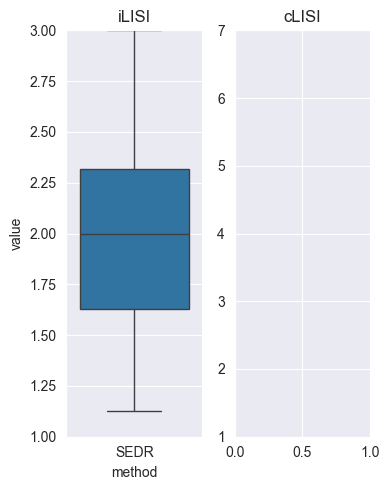

In [12]:
import harmonypy as hm

iLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
#cLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'SEDR',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
#sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
#print(np.median(cLISI))

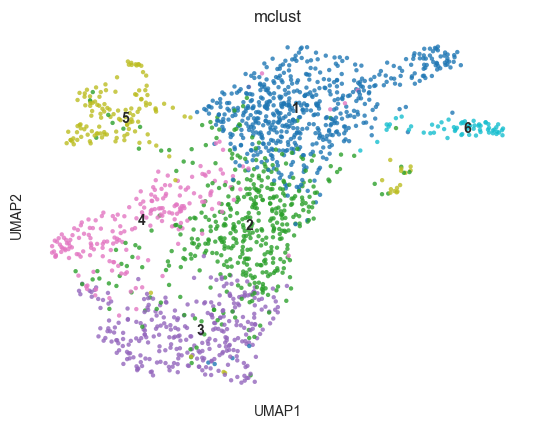

In [13]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色
import scanpy as sc
import matplotlib.pyplot as plt

sc.pp.neighbors(adata, use_rep='SEDR', metric='cosine', n_neighbors=15)  # 可调整 n_neighbors
sc.tl.umap(adata)  # 调整 min_dist 参数优化聚类

sc.pl.umap(
    adata,
    color=['mclust'],
    size=40,  # 调整点大小
    alpha=0.8,  # 调整透明度
    palette='tab10',  # 自定义调色板
    legend_loc='on data'
)

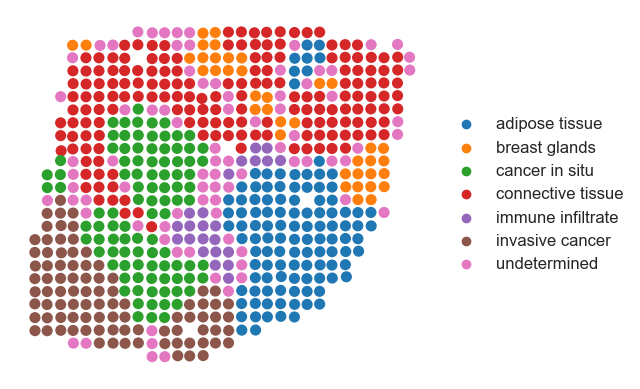

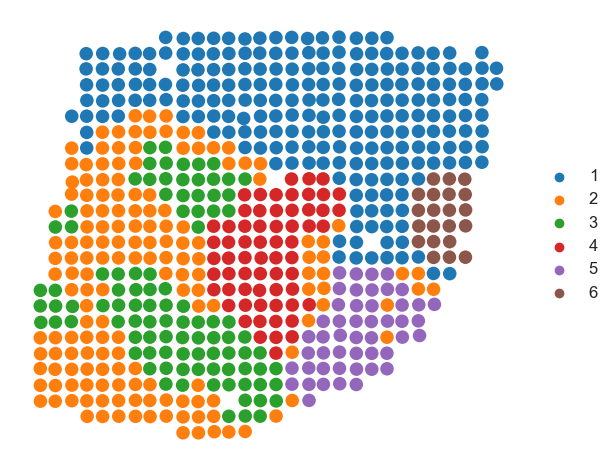

In [14]:
import matplotlib.pyplot as plt


adata_tmp_A1 = adata[adata.obs['batch_name'] == String+str(1)]
adata_tmp_A1.uns = adata_st_list_raw[1].uns

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['annotation'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['mclust'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='annotation',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='mclust',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

plt.tight_layout()

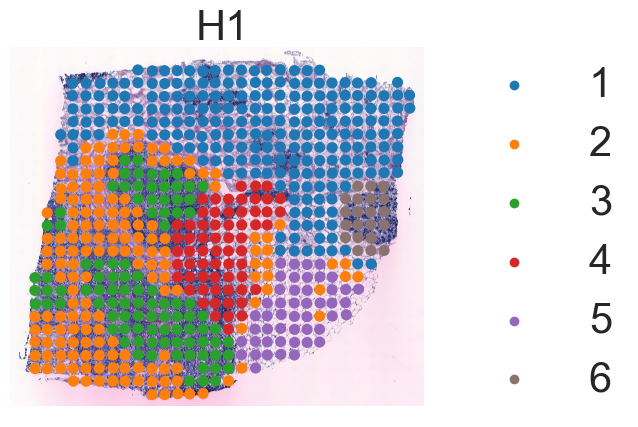

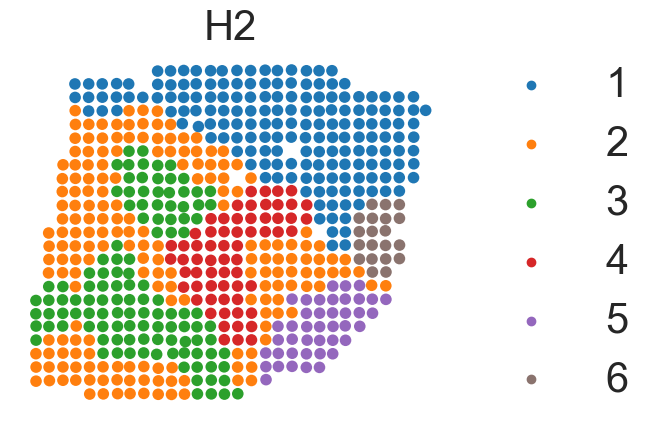

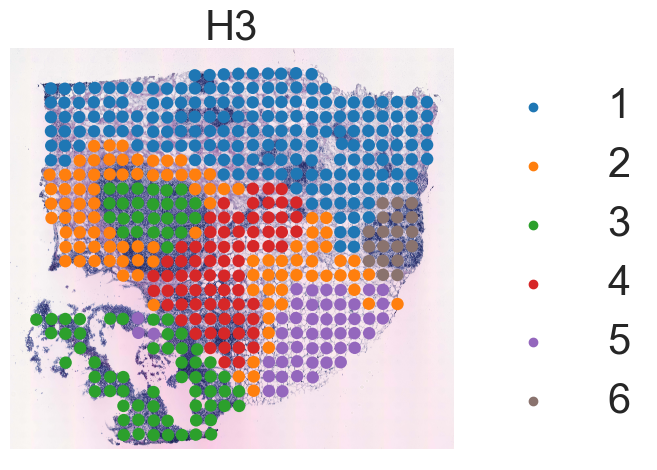

In [15]:
import matplotlib.pyplot as plt

cluster_colors = {
    1: '#1f77b4',  # Cluster 0 -> 蓝色
    2: '#ff7f0e',  # Cluster 1 -> 橙色
    3: '#2ca02c',  # Cluster 2 -> 绿色
    4: '#d62728',  # Cluster 3 -> 红色
    5: '#9467bd',  # Cluster 4 -> 紫色
    6: '#8a736e'   # Cluster 5 -> 
}


for i, slice_name in enumerate(slice_use):
    adata_tmp = adata[adata.obs['batch_name'] == String+str(i+1)]
    adata_tmp.uns = adata_st_list_raw[i].uns
    sc.pl.spatial(adata_tmp, img_key='hires', color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=30, show=False, frameon=False, spot_size=250,
                  palette=cluster_colors)
    plt.title(f'{slice_name}', fontsize=30)
    plt.savefig(f"D:\\njy\MutipelSliceSTD\MS\论文图表设计\Figure8_BC\FS12\\{String}\SEDR_{i+1}.jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()

## Visualizing

### UMAP